In [7]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Diabetic retinopathy.zip"
extract_path = "/content/diabetic_retinopathy_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [21]:
image_extensions = ('.jpg', '.jpeg', '.png')

total_images = 0

for root, dirs, files in os.walk(extract_path):
    total_images += len([f for f in files if f.lower().endswith(image_extensions)])

print("Total images in dataset:", total_images)


Total images in dataset: 5676


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam


In [23]:
train_dir = extract_path + "/Diagnosis of Diabetic Retinopathy/train"
val_path = extract_path + "/Diagnosis of Diabetic Retinopathy/valid"
test_dir  = extract_path + "/Diagnosis of Diabetic Retinopathy/test"

**Data Preprocessing**

In [24]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Train (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation & Test (NO augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2076 images belonging to 2 classes.
Found 531 images belonging to 2 classes.
Found 231 images belonging to 2 classes.


**CNN Model**

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

**Compile Model**

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Path to save best model
model_path = '/content/drive/MyDrive/Call back Model/Diabetic Retinopathy.h5'


# Save best model (highest val_accuracy)
checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', verbose=1,
                             save_best_only=True, mode='max')

# Stop training if val_accuracy doesn't improve for 5 epochs
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5,
                               restore_best_weights=True, mode='max', verbose=1)

# Combine callbacks
callbacks_list = [checkpoint, early_stopping]

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [ ]:
history = model.fit(
    train_data,
    epochs=15,
    validation_data=val_data,
    callbacks=callbacks_list
)



Epoch 1/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.6344 - loss: 0.6381
Epoch 1: val_accuracy improved from None to 0.88324, saving model to /content/drive/MyDrive/Call back Model/Diabetic Retinopathy.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Call back Model/Diabetic Retinopathy.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 51s 656ms/step - accuracy: 0.7028 - loss: 0.5780 - val_accuracy: 0.8832 - val_loss: 0.3362
Epoch 2/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.8227 - loss: 0.4138
Epoch 2: val_accuracy improved from 0.88324 to 0.91525, saving model to /content/drive/MyDrive/Call back Model/Diabetic Retinopathy.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Call back Model/Diabetic Retinopathy.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 35s 540ms/step - accuracy: 0.8304 - loss: 0.3911 - val_accuracy: 0.9153 - val_loss: 0.2349
Epoch 3/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.8783 - loss: 0.3016
Epoch 3: val_accuracy improved from 0.91525 to 0.92467, saving model to /content/drive/MyDrive/Call back Model/Diabetic Retinopathy.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Call back Model/Diabetic Retinopathy.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 33s 509ms/step - accuracy: 0.8733 - loss: 0.3100 - val_accuracy: 0.9247 - val_loss: 0.2205
Epoch 4/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.8997 - loss: 0.2794
Epoch 4: val_accuracy improved from 0.92467 to 0.93220, saving model to /content/drive/MyDrive/Call back Model/Diabetic Retinopathy.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Call back Model/Diabetic Retinopathy.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 34s 520ms/step - accuracy: 0.9070 - loss: 0.2571 - val_accuracy: 0.9322 - val_loss: 0.1919
Epoch 5/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9072 - loss: 0.2395
Epoch 5: val_accuracy improved from 0.93220 to 0.94162, saving model to /content/drive/MyDrive/Call back Model/Diabetic Retinopathy.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Call back Model/Diabetic Retinopathy.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 40s 510ms/step - accuracy: 0.9128 - loss: 0.2323 - val_accuracy: 0.9416 - val_loss: 0.1864
Epoch 6/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.9167 - loss: 0.2281
Epoch 6: val_accuracy did not improve from 0.94162
65/65 ━━━━━━━━━━━━━━━━━━━━ 30s 462ms/step - accuracy: 0.9171 - loss: 0.2253 - val_accuracy: 0.9341 - val_loss: 0.2066
Epoch 7/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9380 - loss: 0.1983
Epoch 7: val_accuracy did not improve from 0.94162
65/65 ━━━━━━━━━━━━━━━━━━━━ 28s 424ms/step - accuracy: 0.9297 - loss: 0.2112 - val_accuracy: 0.9379 - val_loss: 0.1791
Epoch 8/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9238 - loss: 0.2259
Epoch 8: val_accuracy did not improve from 0.94162
65/65 ━━━━━━━━━━━━━━━━━━━━ 28s 424ms/step - accuracy: 0.9302 - loss: 0.2024 - val_accuracy: 0.9322 - val_loss: 0.2043
Epoch 9/15
65/65 ━━


Epoch 9: finished saving model to /content/drive/MyDrive/Call back Model/Diabetic Retinopathy.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 30s 455ms/step - accuracy: 0.9340 - loss: 0.1958 - val_accuracy: 0.9435 - val_loss: 0.1831
Epoch 10/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9326 - loss: 0.2025
Epoch 10: val_accuracy did not improve from 0.94350
65/65 ━━━━━━━━━━━━━━━━━━━━ 30s 466ms/step - accuracy: 0.9287 - loss: 0.2097 - val_accuracy: 0.9397 - val_loss: 0.1784
Epoch 11/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9375 - loss: 0.1947
Epoch 11: val_accuracy did not improve from 0.94350
65/65 ━━━━━━━━━━━━━━━━━━━━ 27s 417ms/step - accuracy: 0.9359 - loss: 0.1974 - val_accuracy: 0.9397 - val_loss: 0.1886
Epoch 12/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9385 - loss: 0.1862
Epoch 12: val_accuracy did not improve from 0.94350
65/65 ━━━━━━━━━━━━━━━━━━━━ 27s 410ms/step - accuracy: 0.9364 - loss: 0.1870 - val_accuracy: 0.9360 - val_loss: 0.1953
Epoch 13/15
6

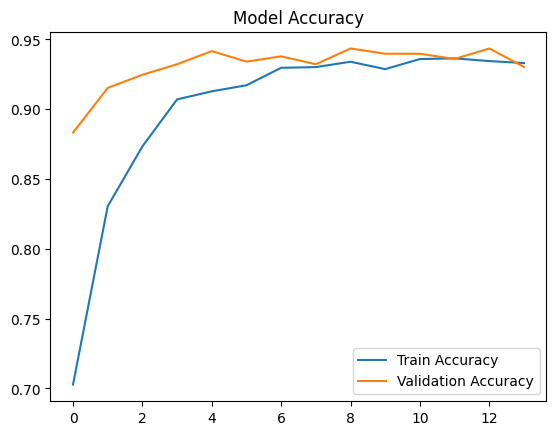

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()


**Load Save Model**

In [ ]:
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
from tensorflow import keras
from tensorflow.keras.preprocessing import image

model_path = '/content/drive/MyDrive/Call back Model/Diabetic Retinopathy.h5'
model1 = keras.models.load_model(model_path)

**Predict Image with Diabetic Retinopathy Disease**

In [9]:
import matplotlib.image as mpimg
imgg=mpimg.imread('/content/drive/MyDrive/DRimg.png')

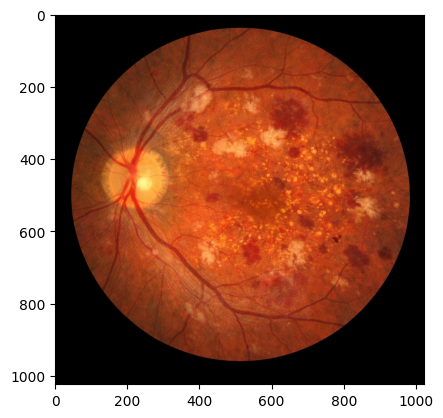

In [10]:
plt.imshow(imgg)
plt.show()

In [17]:
imgg.shape

(1024, 1024, 3)

In [25]:
import cv2
imgg=cv2.resize(imgg,(IMG_SIZE[0],IMG_SIZE[1]))

In [27]:
imgg_input=imgg.reshape((1,IMG_SIZE[0],IMG_SIZE[1],3))

In [29]:
model1.predict(imgg_input).round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([[0.04, 0.96]], dtype=float32)

**Predict image with No Diabetic Retinopathy Disease**

In [30]:
imgg1=mpimg.imread('/content/drive/MyDrive/DR img1.png')

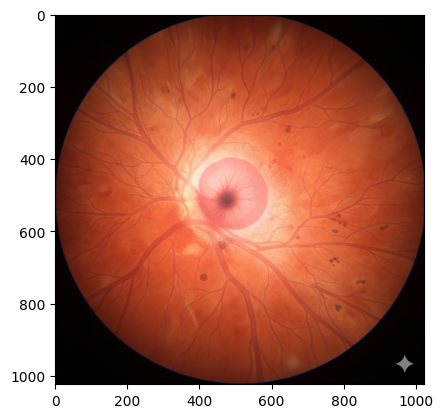

In [31]:
plt.imshow(imgg1)
plt.show()

In [32]:
imgg1.shape

(1024, 1024, 4)

In [34]:
imgg1=cv2.resize(imgg1,(IMG_SIZE[0],IMG_SIZE[1]))

In [36]:
imgg_input1 = imgg1[:, :, :3].reshape((1, IMG_SIZE[0], IMG_SIZE[1], 3))

In [37]:
model1.predict(imgg_input1).round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


array([[0.82, 0.18]], dtype=float32)